In [968]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c
lumapiFile = "C:\\Program Files\\Lumerical\\v261\\api\\python\\lumapi.py"

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("lumapi", lumapiFile)
lumapi = importlib.util.module_from_spec(spec)
sys.modules["lumapi"] = lumapi
spec.loader.exec_module(lumapi)

import lumapi

In [969]:
from IPython.core.display import HTML
from IPython.display import display, Math
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

figsize(8, 4)

In [970]:
fdtdApi = lumapi.FDTD(hide=False)

#units

um = 1e-6
nm = 1e-9

## Device dimensions ##

In [971]:
## device dimensions

W1 = 1.48*um
W2 = 1.48*um
W3 = 1.6*um
W4 = 0.5*um
W5 = 0.7*um
W6 = 0.2*um
L1 = 1*um
L2 = 2.4*um
L3 = 1.6*um
H = 220*nm

rect_span = 2*um

#Materials:
material = 'Si (Silicon) - Palik'
sub_material = 'SiO2 (Glass) - Palik'

#FDTD, ports and monitors:

x_span_fdtd = 2*(L1 + L2 + L3) + 1.4*rect_span
y_span_fdtd = 5*W1
z_span_fdtd = 7*H
simulation_time = 10*x_span_fdtd/c

wavelength = 1550*nm
start_wavelength = 1500*nm
stop_wavelength = 1600*nm
number_of_frequency_points = 51
mesh_accuracy = 5

indxLambda = 24

x_rect = [-L1 - L2 - L3 - rect_span/2, -L1 - L2 - L3 - rect_span/2, L1 + L2 + L3 + rect_span/2, L1 + L2 + L3 + rect_span/2]

x_port = [-x_span_fdtd/2 + 0.55*um, -x_span_fdtd/2 + 0.55*um, x_span_fdtd/2 - 0.55*um, x_span_fdtd/2 - 0.55*um]
y_port = [(W5 + W6)/2, -(W5 + W6)/2, (W5 + W6)/2, -(W5 + W6)/2]

direction = ['Forward', 'Forward', 'Backward', 'Backward']


## Building the device ##

In [972]:
fdtdApi.addstructuregroup()
fdtdApi.set('name', 'group')

### principal device ###

In [973]:
fdtdApi.addobject('linear_taper')
fdtdApi.set('name', 'taper_1')
fdtdApi.set('angle_side', 90)
fdtdApi.set('len', L1)
fdtdApi.set('width_l', W4)
fdtdApi.set('width_r', W5)
fdtdApi.set('thickness', H)
fdtdApi.set('x', -L3 - L2 - L1/2)
fdtdApi.set('y', W6/2 + W5/2)
fdtdApi.set('material', material)
fdtdApi.addtogroup('group')

fdtdApi.addobject('linear_taper')
fdtdApi.set('name', 'taper_2')
fdtdApi.set('angle_side', 90)
fdtdApi.set('len', L1)
fdtdApi.set('width_l', W4)
fdtdApi.set('width_r', W5)
fdtdApi.set('thickness', H)
fdtdApi.set('x', -L3 - L2 - L1/2)
fdtdApi.set('y', -W6/2 - W5/2)
fdtdApi.set('material', material)

fdtdApi.addobject('linear_taper')
fdtdApi.set('name', 'MMI_part_1')
fdtdApi.set('angle_side', 90)
fdtdApi.set('len', L2)
fdtdApi.set('width_l', 2*W5+W6)
fdtdApi.set('width_r', W1)
fdtdApi.set('thickness', H)
fdtdApi.set('x', -L3 - L2/2)
fdtdApi.set('y', 0)
fdtdApi.set('material', material)

fdtdApi.addobject('linear_taper')
fdtdApi.set('name', 'MMI_part_2')
fdtdApi.set('angle_side', 90)
fdtdApi.set('len', L3)
fdtdApi.set('width_l', W1)
fdtdApi.set('width_r', W2)
fdtdApi.set('thickness', H)
fdtdApi.set('x', -L3/2)
fdtdApi.set('y', 0)
fdtdApi.set('material', material)

fdtdApi.addobject('linear_taper')
fdtdApi.set('name', 'MMI_part_3')
fdtdApi.set('angle_side', 90)
fdtdApi.set('len', L3)
fdtdApi.set('width_l', W2)
fdtdApi.set('width_r', W1)
fdtdApi.set('thickness', H)
fdtdApi.set('x', L3/2)
fdtdApi.set('y', 0)
fdtdApi.set('material', material)

fdtdApi.addobject('linear_taper')
fdtdApi.set('name', 'MMI_part_4')
fdtdApi.set('angle_side', 90)
fdtdApi.set('len', L2)
fdtdApi.set('width_l', W1)
fdtdApi.set('width_r', 2*W5+W6)
fdtdApi.set('thickness', H)
fdtdApi.set('x', L3 + L2/2)
fdtdApi.set('y', 0)
fdtdApi.set('material', material)

fdtdApi.addobject('linear_taper')
fdtdApi.set('name', 'taper_3')
fdtdApi.set('angle_side', 90)
fdtdApi.set('len', L1)
fdtdApi.set('width_l', W5)
fdtdApi.set('width_r', W4)
fdtdApi.set('thickness', H)
fdtdApi.set('x', L3 + L2 + L1/2)
fdtdApi.set('y', W6/2 + W5/2)
fdtdApi.set('material', material)

fdtdApi.addobject('linear_taper')
fdtdApi.set('name', 'taper_4')
fdtdApi.set('angle_side', 90)
fdtdApi.set('len', L1)
fdtdApi.set('width_l', W5)
fdtdApi.set('width_r', W4)
fdtdApi.set('thickness', H)
fdtdApi.set('x', L3 + L2 + L1/2)
fdtdApi.set('y', -W6/2 - W5/2)
fdtdApi.set('material', material)

### auxiliary rectangles ###

In [974]:
for i in range(1,5,1):
    fdtdApi.addrect()
    fdtdApi.set('name', 'rect_' + str(i))
    fdtdApi.set('x', x_rect[i-1])
    fdtdApi.set('x span', rect_span)
    fdtdApi.set('y', y_port[i-1])
    fdtdApi.set('y span', W4)
    fdtdApi.set('z', 0)
    fdtdApi.set('z span', H)
    fdtdApi.set('material', material)

### solver and monitors ###

In [975]:
# add FDTD

fdtdApi.addfdtd()
fdtdApi.set('x', 0)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', 0)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('z', 0)
fdtdApi.set('z span', z_span_fdtd)

fdtdApi.set('background material', sub_material)
fdtdApi.set('global source wavelength start', start_wavelength)
fdtdApi.set('global source wavelength stop', stop_wavelength)
fdtdApi.set('global monitor frequency points', number_of_frequency_points)
fdtdApi.set('Mesh accuracy', mesh_accuracy)
fdtdApi.set('simulation time', simulation_time)

# add ports

for i in range(1,5,1):
    fdtdApi.addport()
    fdtdApi.set('name', 'port_' + str(i))
    fdtdApi.set('injection axis', 'x-axis')
    fdtdApi.set('direction', direction[i-1])
    fdtdApi.set('mode selection', 'user select')
    fdtdApi.set('selected mode numbers', np.block([1]))
    fdtdApi.set('x', x_port[i-1])
    fdtdApi.set('y', y_port[i-1])
    fdtdApi.set('y span', W5 + 0.8*W6)
    fdtdApi.set('z', 0)
    fdtdApi.set('z span', 4*H)
    

# add monitors

fdtdApi.addindex()
fdtdApi.set('name', 'index')
fdtdApi.set('x', 0)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', 0)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('z', 0)

fdtdApi.addprofile()
fdtdApi.set('name', 'profile_xy')
fdtdApi.set('override global monitor settings', True)
fdtdApi.set('frequency points', number_of_frequency_points)
fdtdApi.set('x', 0)
fdtdApi.set('x span', x_span_fdtd)
fdtdApi.set('y', 0)
fdtdApi.set('y span', y_span_fdtd)
fdtdApi.set('z', 0)


In [976]:
fdtdApi.save('MMI2X2')
#fdtdApi.close()

## analyzing the device's behavior  ##

In [977]:
fdtdApi.run()

In [978]:
index_x = np.squeeze(fdtdApi.getdata('index', 'index_x').real)
x_device = np.squeeze(fdtdApi.getdata('index', 'x'))/um
y_device = np.squeeze(fdtdApi.getdata('index', 'y'))/um

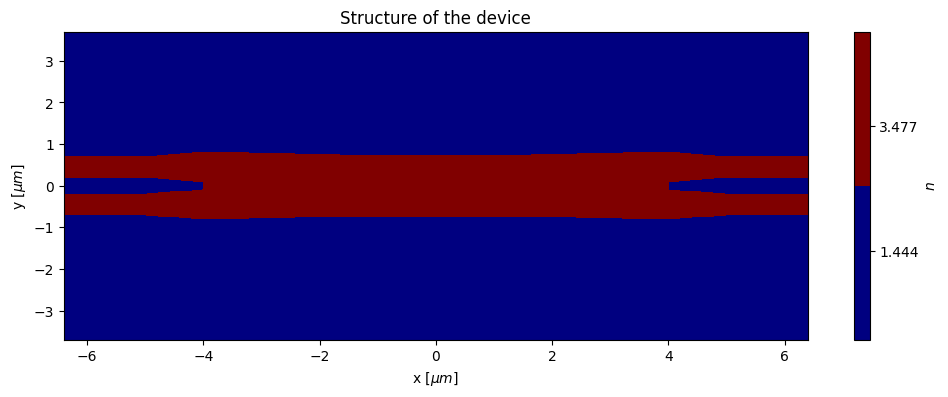

In [979]:
X, Y = np.meshgrid(x_device, y_device)
X, Y = np.transpose(X), np.transpose(Y)
v = np.linspace(np.min(index_x), np.max(index_x), 2)

fig0 = plt.figure(figsize=(12,4))
im0 = plt.contourf(X, Y, index_x, 0, cmap = plt.get_cmap('jet'), vmin = v[0], vmax = v[-1], origin = 'lower')
colorbar = plt.colorbar(im0, label = r'$n$')
colorbar.set_ticks(v)
plt.xlabel(r'x [$\mu m$]')
plt.ylabel(r'y [$\mu m$]')
plt.title('Structure of the device')

plt.show()

In [980]:
eField_x = np.squeeze(fdtdApi.getdata('profile_xy', 'Ex'))
eField_y = np.squeeze(fdtdApi.getdata('profile_xy', 'Ey'))
eField_z = np.squeeze(fdtdApi.getdata('profile_xy', 'Ez'))

eField_abs2 = np.abs(eField_x)**2 + np.abs(eField_y)**2 + np.abs(eField_z)**2
eField_abs = np.sqrt(eField_abs2)

x_efield = fdtdApi.getdata('profile_xy', 'x')
y_efield = fdtdApi.getdata('profile_xy', 'y')
central_wavelength = nu2lambda(fdtdApi.getdata('profile_xy', 'f'))
xmin = np.min(x_efield) / um
xmax = np.max(x_efield) / um
ymin = np.min(y_efield) / um
ymax = np.max(y_efield) / um

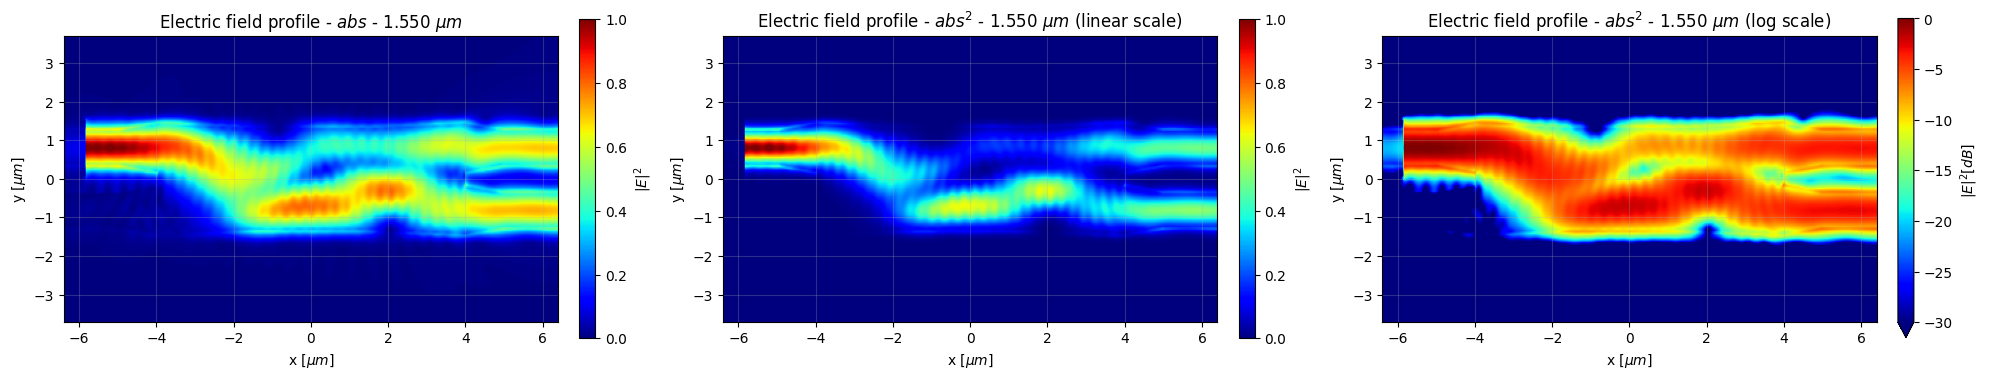

In [981]:
fig1, ax1 = plt.subplots(1,3,figsize=(20,4))

im1 = ax1[0].imshow(np.rot90(eField_abs[:,:,indxLambda]), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = 'jet', aspect = 'equal')
#ticks_linear = np.linspace(0, 1, 11)

colorbar = plt.colorbar(im1,fraction = 0.03, pad =0.04, label = r'$|E|^2$')

ax1[0].set_xlabel(r'x [$\mu m$]')
ax1[0].set_ylabel(r'y [$\mu m$]')
ax1[0].set_title(r'Electric field profile - $abs$ - %4.3f $\mu m$' % (central_wavelength[indxLambda,0]/ um))
ax1[0].grid(which='major', alpha = 0.25)

im2 = ax1[1].imshow(np.rot90(eField_abs2[:,:,indxLambda]), extent=[xmin, xmax, ymin, ymax], vmin = 0, vmax = 1, cmap = 'jet', aspect = 'equal')
ticks_linear = np.linspace(0, 1, 11)

colorbar = plt.colorbar(im2,fraction = 0.03, pad =0.04, label = r'$|E|^2$')

ax1[1].set_xlabel(r'x [$\mu m$]')
ax1[1].set_ylabel(r'y [$\mu m$]')
ax1[1].set_title(r'Electric field profile - $abs^{2}$ - %4.3f $\mu m$ (linear scale)' % (central_wavelength[indxLambda,0]/ um))
ax1[1].grid(which='major', alpha = 0.25)

im3 = ax1[2].imshow(np.rot90(10*np.log10(eField_abs2[:,:,indxLambda])), extent = [xmin, xmax, ymin, ymax], vmin = -30, vmax = 0, cmap = 'jet', aspect = 'equal')

colorbar = plt.colorbar(im3, fraction = 0.03, pad = 0.04, label = r'$|E|^2 [dB]$', extend = 'min')

ax1[2].set_xlabel(r'x [$\mu m$]')
ax1[2].set_ylabel(r'y [$\mu m$]')
ax1[2].set_title(r'Electric field profile - $abs^{2}$ - %4.3f $\mu m$ (log scale)' % (central_wavelength[indxLambda,0]/ um))
ax1[2].grid(which='major', alpha = 0.25)

plt.tight_layout()
plt.show()

### Visualizing the transmission in each port and the insertion loss ###

In [ ]:
T_port_1 = fdtdApi.getresult('FDTD::ports::port_1', 'T')['T']
T_port_2 = fdtdApi.getresult('FDTD::ports::port_2', 'T')['T']
T_port_3 = fdtdApi.getresult('FDTD::ports::port_3', 'T')['T']
T_port_4 = fdtdApi.getresult('FDTD::ports::port_4', 'T')['T']

loss_2 = 10*(np.log10(T_port_1) - np.log10(T_port_2))
loss_3 = 10*(np.log10(T_port_1) - np.log10(T_port_3))
loss_4 = 10*(np.log10(T_port_1) - np.log10(T_port_4))

ports_lambda = fdtdApi.getresult('FDTD::ports::port_1', 'T')['lambda']/nm

C:\Users\LucasGabriel\AppData\Local\Temp\ipykernel_22244\2147402016.py:6: RuntimeWarning: invalid value encountered in log10
  loss_2 = 10*(np.log10(T_port_1) - np.log10(T_port_2))


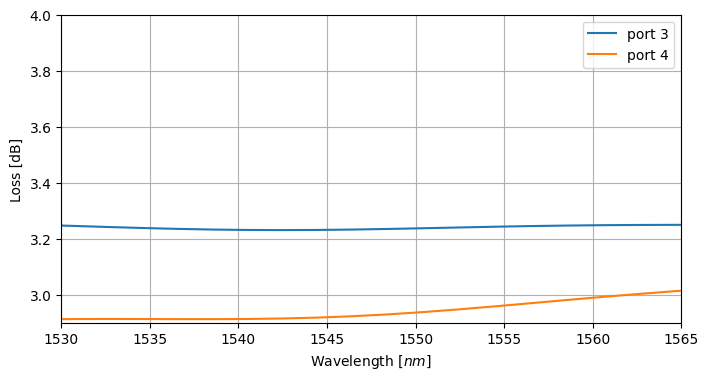

In [983]:
plt.plot(ports_lambda, loss_3, label = 'port 3')
plt.plot(ports_lambda, loss_4, label = 'port 4')
plt.xlabel(r'Wavelength [$nm$]')
plt.ylabel(r'Loss [dB]')
plt.legend(loc = 'best')
plt.grid(True)
plt.xlim([1530, 1565])
plt.ylim([2.9,4])
plt.show()

In [984]:
fdtdApi.close()